<a href="https://colab.research.google.com/github/mashan275/data-science-2024/blob/main/Pertemuan7_Hasta_satriya_240401010207.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INFO DATASET
Shape : (300, 4)

   pengalaman  edu      kota       gaji
0    7.490802    0   Jakarta  21.953247
1   19.014286    1   Jakarta  46.721665
2   14.639879    2  Surabaya  34.952649
3   11.973170    2   Bandung  32.437143
4    3.120373    2   Jakarta  17.384265

       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22



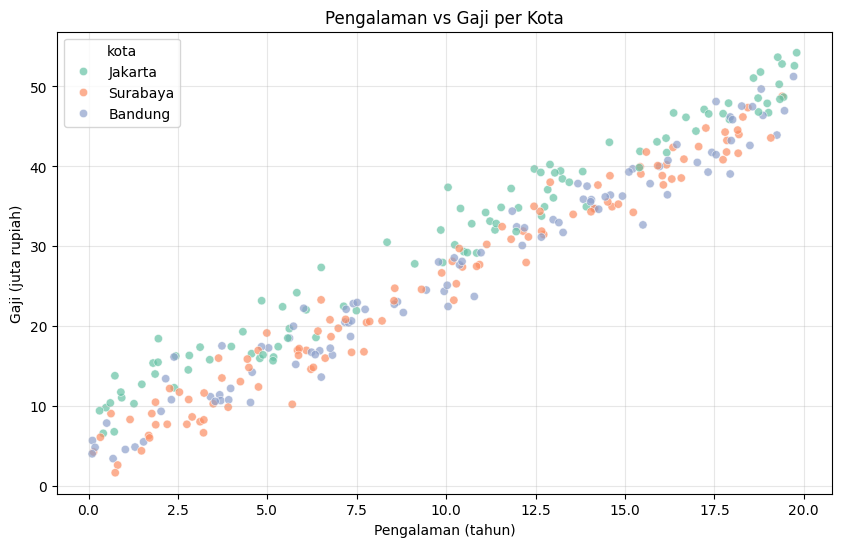


KOLOM SETELAH ENCODING
['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']

TRAIN TEST SPLIT
Train : 240 baris
Test  : 60 baris

HASIL MODEL
Intercept (β0) = 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292

METRIK EVALUASI
MAE  = 1.649 juta rupiah
MSE  = 4.507
RMSE = 2.123 juta rupiah
R²   = 0.9740
Variasi data yang dijelaskan model = 97.40%
Selisih RMSE-MAE = 0.474


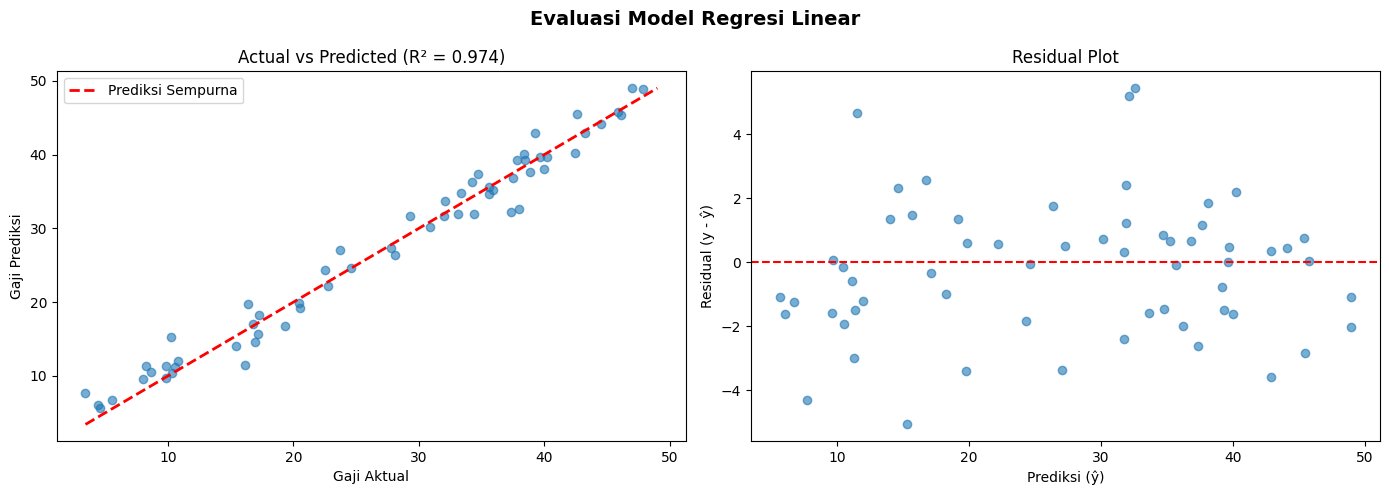


INTERPRETASI
Rata-rata kesalahan prediksi sekitar 1.65 juta rupiah.
Model sangat baik.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# 1. GENERATE DATASET SINTETIS
# =====================================================
# =====================================================
#===========Hasta Satriya 240401010207_IF403===========
# =====================================================
np.random.seed(42)

n = 300

pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n)  # SMA=0, D3=1, S1=2
kota = np.random.choice(
    ['Jakarta', 'Surabaya', 'Bandung'],
    n
)

gaji = (
    3.0
    + 2.2 * pengalaman
    + 1.5 * edu
    + np.where(kota == 'Jakarta', 4.0, 0)
    + np.random.normal(0, 2, n)
)

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})

# =====================================================
# 2. EDA SINGKAT
# =====================================================

print("=" * 50)
print("INFO DATASET")
print("=" * 50)

print("Shape :", df.shape)
print()

print(df.head())
print()

print(df.describe().round(2))
print()

# =====================================================
# 3. VISUALISASI DATA
# =====================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='pengalaman',
    y='gaji',
    hue='kota',
    palette='Set2',
    alpha=0.7
)

plt.title('Pengalaman vs Gaji per Kota')
plt.xlabel('Pengalaman (tahun)')
plt.ylabel('Gaji (juta rupiah)')
plt.grid(True, alpha=0.3)

plt.show()

# =====================================================
# 4. PREPROCESSING
# =====================================================

# One-Hot Encoding

df_encoded = pd.get_dummies(
    df,
    columns=['kota'],
    drop_first=True
)

print()
print("=" * 50)
print("KOLOM SETELAH ENCODING")
print("=" * 50)

print(df_encoded.columns.tolist())

# =====================================================
# 5. SPLIT FITUR DAN TARGET
# =====================================================

X = df_encoded.drop('gaji', axis=1)
y = df_encoded['gaji']

# =====================================================
# 6. TRAIN TEST SPLIT
# =====================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print()
print("=" * 50)
print("TRAIN TEST SPLIT")
print("=" * 50)

print(f"Train : {X_train.shape[0]} baris")
print(f"Test  : {X_test.shape[0]} baris")

# =====================================================
# 7. STANDARD SCALER
# =====================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# =====================================================
# 8. TRAIN MODEL
# =====================================================

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_s, y_train)

# =====================================================
# 9. KOEFISIEN MODEL
# =====================================================

print()
print("=" * 50)
print("HASIL MODEL")
print("=" * 50)

print(f"Intercept (β0) = {model.intercept_:.3f}")
print()

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_
})

coef_df = coef_df.sort_values(
    by='Koefisien',
    ascending=False
)

print(coef_df.round(3).to_string(index=False))

# =====================================================
# 10. PREDIKSI
# =====================================================

y_pred = model.predict(X_test_s)

# =====================================================
# 11. EVALUASI
# =====================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print()
print("=" * 50)
print("METRIK EVALUASI")
print("=" * 50)

print(f"MAE  = {mae:.3f} juta rupiah")
print(f"MSE  = {mse:.3f}")
print(f"RMSE = {rmse:.3f} juta rupiah")
print(f"R²   = {r2:.4f}")

print(
    f"Variasi data yang dijelaskan model = {r2*100:.2f}%"
)

print(
    f"Selisih RMSE-MAE = {(rmse-mae):.3f}"
)

# =====================================================
# 12. VISUALISASI EVALUASI
# =====================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# -----------------------------------------------------
# ACTUAL VS PREDICTED
# -----------------------------------------------------

axes[0].scatter(
    y_test,
    y_pred,
    alpha=0.6
)

min_val = min(
    y_test.min(),
    y_pred.min()
)

max_val = max(
    y_test.max(),
    y_pred.max()
)

axes[0].plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label='Prediksi Sempurna'
)

axes[0].set_title(
    f'Actual vs Predicted (R² = {r2:.3f})'
)

axes[0].set_xlabel(
    'Gaji Aktual'
)

axes[0].set_ylabel(
    'Gaji Prediksi'
)

axes[0].legend()

# -----------------------------------------------------
# RESIDUAL PLOT
# -----------------------------------------------------

residuals = y_test - y_pred

axes[1].scatter(
    y_pred,
    residuals,
    alpha=0.6
)

axes[1].axhline(
    y=0,
    color='red',
    linestyle='--'
)

axes[1].set_title(
    'Residual Plot'
)

axes[1].set_xlabel(
    'Prediksi (ŷ)'
)

axes[1].set_ylabel(
    'Residual (y - ŷ)'
)

# -----------------------------------------------------

plt.suptitle(
    'Evaluasi Model Regresi Linear',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    'evaluasi_regresi.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# =====================================================
# 13. INTERPRETASI OTOMATIS
# =====================================================

print()
print("=" * 50)
print("INTERPRETASI")
print("=" * 50)

print(
    f"Rata-rata kesalahan prediksi sekitar "
    f"{mae:.2f} juta rupiah."
)

if r2 >= 0.90:
    print("Model sangat baik.")
elif r2 >= 0.80:
    print("Model baik.")
elif r2 >= 0.70:
    print("Model cukup baik.")
else:
    print("Model masih perlu ditingkatkan.")